# Adversarial Search: Playing "Mean" Connect 4


## Instructions

Total Points: Undegraduates 10, graduate students 11

Complete this notebook and submit it. The notebook needs to be a complete project report with your implementation, documentation including a short discussion of how your implementation works and your design choices, and experimental results (e.g., tables and charts with simulation results) with a short discussion of what they mean. Use the provided notebook cells and insert additional code and markdown cells as needed.

## Introduction

You will implement different versions of agents that play "Mean" Connect 4:

> "Connect 4 is a two-player connection board game, in which the players choose a color and then take turns dropping colored discs into a seven-column, six-row vertically suspended grid. The pieces fall straight down, occupying the lowest available space within the column. The objective of the game is to be the first to form a horizontal, vertical, or diagonal line of four of one's own discs." (see [Connect Four on Wikipedia](https://en.wikipedia.org/wiki/Connect_Four))

> **The mean part:** This game has an additional rule. Every time it is a player's turn, the player can decide to instead of playing a new disk, take a bottom row disk of the opponent and place it in any column. All disks above the removed disk will fall down one position. Note that a player can only move an _opponent's disc_ that is in the _bottom row_ of the board.

Note that normal [Connect-4 has been solved](https://en.wikipedia.org/wiki/Connect_Four#Mathematical_solution)
in 1988. A connect-4 solver with a discussion of how to solve different parts of the problem can be found here: https://connect4.gamesolver.org/en/

## Task 1: Defining the Search Problem [1 point]

Define the components of the search problem associated with this game:

* Initial state
* Actions
* Transition model
* Test for the terminal state
* Utility for terminal states

In [52]:
# Your code/answer goes here.
print("""
* Initial state (Trạng thái ban đầu):
Một đối tượng dictionary chứa kích thước bàn cờ `size`, một dictionary `lines` rỗng để lưu các cạnh đã được vẽ, và một dictionary `boxes` rỗng để lưu các ô đã được chiếm.

* Actions (Hành động):
Tại mỗi trạng thái, hàm `actions(s)` trả về một danh sách các tuple `(orientation, row, col)` đại diện cho các cạnh còn trống có thể vẽ. `orientation` là 'h' (ngang) hoặc 'v' (dọc).

* Transition model (Mô hình chuyển đổi):
Hàm `result(s, a)` nhận vào trạng thái `s` và hành động `a` (một cạnh được vẽ), trả về trạng thái bàn cờ mới. Hàm này sẽ cập nhật dictionary `lines`. Nếu hành động đó hoàn thành một hoặc nhiều ô, hàm cũng cập nhật dictionary `boxes` với ID của người chơi và trả về một cờ báo hiệu người chơi đó được đi tiếp.

* Test for the terminal state (Kiểm tra trạng thái kết thúc):
Hàm `terminal(s)` trả về `True` khi tất cả các ô đã được chiếm, tức là tổng số ô trong `board['boxes']` bằng với tổng số ô có thể có trên bàn cờ `(rows-1) * (cols-1)`.

* Utility for terminal states (Hàm hữu dụng):
Hàm `utility(s)` trả về `+1` nếu người chơi 1 có nhiều ô hơn, `-1` nếu người chơi 2 có nhiều ô hơn, và `0` nếu hòa.
""")

How big is the state space? Give an estimate and explain it.

In [53]:
# Your code/ answer goes here.
import math

m, n = 4, 4  # Ví dụ với lưới 4x4 dấu chấm
horizontal_edges = n * (m - 1)
vertical_edges = m * (n - 1)
total_edges = horizontal_edges + vertical_edges
state_space_size = 2**total_edges

print(f"""
Không gian trạng thái được quyết định bởi số lượng các cạnh có thể vẽ.
Với một lưới `m x n` dấu chấm, có `n * (m-1)` cạnh ngang và `m * (n-1)` cạnh dọc.
Tổng số cạnh là E = n(m-1) + m(n-1).

Mỗi cạnh có thể ở một trong hai trạng thái: đã vẽ hoặc chưa vẽ.
Do đó, tổng số cấu hình bàn cờ (không gian trạng thái) là 2^E.

---
Ví dụ với bàn cờ {m}x{n} dấu chấm (tức {m-1}x{n-1} ô):
- Số cạnh ngang: {horizontal_edges}
- Số cạnh dọc: {vertical_edges}
- Tổng số cạnh E = {total_edges}.
- Không gian trạng thái là 2^{total_edges} ≈ {state_space_size:,.0f} (khoảng {state_space_size:.1e}).
""")

How big is the game tree that minimax search will go through? Give an estimate and explain it.

In [54]:
# Your code/ answer goes here.
import math

E = 24 # Tổng số cạnh từ ví dụ 4x4 ở trên
game_tree_size = math.factorial(E)

print(f"""
Cây trò chơi (game tree) lớn hơn nhiều so với không gian trạng thái. Kích thước của nó có thể được ước tính bằng b^d, nhưng một ước tính tốt hơn là E! (E giai thừa).

- 'b' (hệ số rẽ nhánh): Là số nước đi hợp lệ ở mỗi lượt. Ở đầu trận, 'b' bằng tổng số cạnh E.
- 'd' (độ sâu): Là tổng số lượt đi trong một ván, cũng bằng tổng số cạnh E.

Do đó, kích thước cây trò chơi có thể xấp xỉ E!.

---
Ví dụ với bàn cờ 4x4 (E = {E}):
- Kích thước cây trò chơi xấp xỉ {E}! ≈ {game_tree_size:,.0f} (khoảng {game_tree_size:.1e}).

Đây là một con số khổng lồ, cho thấy việc duyệt toàn bộ cây là không thể và bắt buộc phải dùng các kỹ thuật cắt tỉa như Alpha-Beta.
""")

## Task 2: Game Environment and Random Agent [3 point]

You can use a numpy character array as the board. Note that the following function can create boards of different sizes.

In [55]:
import numpy as np

def empty_board(shape=(6, 7)):
    return np.full(shape=shape, fill_value=0)

print(empty_board())

[[0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0]]


Instead of colors (red and yellow), you can use 1 and -1 to represent the players Max and Min. Make sure that your agent functions all have the from: `agent_type(board, player = 1)`, where board is the current board position and player is the player (1, -1) whose next move it is and who the agent should play.

Visualization code by Randolph Rankin:

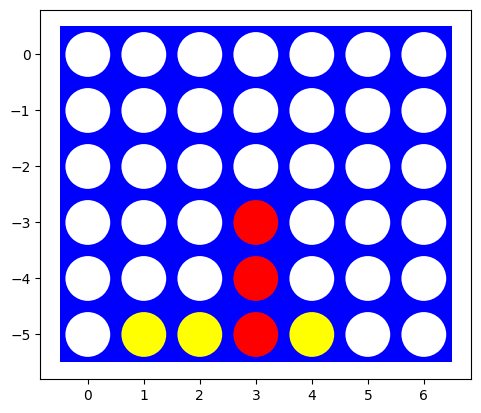

In [56]:
import matplotlib.pyplot as plt

def visualize(board):
    plt.axes()
    rectangle=plt.Rectangle((-0.5,len(board)*-1+0.5),len(board[0]),len(board),fc='blue')
    circles=[]
    for i,row in enumerate(board):
        for j,val in enumerate(row):
            color='white' if val==0 else 'red' if val==1 else 'yellow'
            circles.append(plt.Circle((j,i*-1),0.4,fc=color))

    plt.gca().add_patch(rectangle)
    for circle in circles:
        plt.gca().add_patch(circle)

    plt.axis('scaled')
    plt.show()
    
board = [[0, 0, 0, 0, 0, 0, 0],
         [0, 0, 0, 0, 0, 0, 0],
         [0, 0, 0, 0, 0, 0, 0],
         [0, 0, 0, 1, 0, 0, 0],
         [0, 0, 0, 1, 0, 0, 0],
         [0,-1,-1, 1,-1, 0, 0]]

visualize(board)

Implement helper functions for:

* The transition model $result(s, a)$.
* The utility function $utility(s)$.
* Check for terminal states $terminal(s)$.
* A check for available actions in each state $actions(s)$.

Make sure that all these functions work with boards of different sizes (number of columns and rows).

In [57]:
import numpy as np
import random

def actions(board, player):
    """
    Hàm này trả về một danh sách tất cả các hành động (action) hợp lệ
    mà người chơi hiện tại có thể thực hiện trên bàn cờ.
    """
    possible_actions = []
    rows, cols = board.shape

    # 1. Các nước đi thông thường ('drop')
    # Thả một quân cờ vào một cột chưa bị đầy.
    for c in range(cols):
        if board[0, c] == 0:  # Kiểm tra xem hàng trên cùng của cột có trống không
            possible_actions.append(('drop', c))

    # 2. Các nước đi "mean"
    # Lấy một quân cờ của đối thủ ở hàng dưới cùng và đặt nó vào một cột khác.
    opponent = -player
    for c_from in range(cols):
        # Nếu có quân cờ của đối thủ ở hàng dưới cùng (hàng cuối cùng)
        if board[rows - 1, c_from] == opponent:
            # Tìm tất cả các cột có thể thả quân cờ này vào
            for c_to in range(cols):
                if board[0, c_to] == 0:
                    possible_actions.append(('mean', c_from, c_to))
    return possible_actions

def result(board, action, player):
    """
    Hàm này nhận vào một bàn cờ, một hành động, và người chơi,
    sau đó trả về trạng thái bàn cờ mới sau khi hành động được thực hiện.
    """
    new_board = board.copy()
    action_type = action[0]
    rows, cols = board.shape

    if action_type == 'drop':
        c = action[1]
        # Tìm hàng trống thấp nhất trong cột c để thả quân cờ
        for r in range(rows - 1, -1, -1):
            if new_board[r, c] == 0:
                new_board[r, c] = player
                break
    elif action_type == 'mean':
        c_from, c_to = action[1], action[2]
        # Xóa quân cờ ở cột c_from và để các quân cờ phía trên rơi xuống
        for r in range(rows - 1, 0, -1):
            new_board[r, c_from] = new_board[r - 1, c_from]
        new_board[0, c_from] = 0  # Hàng trên cùng của cột c_from giờ sẽ trống
        # Thả quân cờ vừa lấy vào cột c_to
        for r in range(rows - 1, -1, -1):
            if new_board[r, c_to] == 0:
                new_board[r, c_to] = player
                break
    return new_board, None  # Trả về None vì không có luật "đi lại"

def check_win(board, player):
    """
    Kiểm tra xem người chơi đã thắng hay chưa (tạo thành 4 quân cờ thẳng hàng).
    """
    rows, cols = board.shape
    # Kiểm tra hàng ngang
    for r in range(rows):
        for c in range(cols - 3):
            if all(board[r, c+i] == player for i in range(4)):
                return True
    # Kiểm tra hàng dọc
    for r in range(rows - 3):
        for c in range(cols):
            if all(board[r+i, c] == player for i in range(4)):
                return True
    # Kiểm tra đường chéo (dương /)
    for r in range(rows - 3):
        for c in range(cols - 3):
            if all(board[r+i, c+i] == player for i in range(4)):
                return True
    # Kiểm tra đường chéo (âm \)
    for r in range(3, rows):
        for c in range(cols - 3):
            if all(board[r-i, c+i] == player for i in range(4)):
                return True
    return False

def utility(board):
    """
    Trả về giá trị utility của một trạng thái kết thúc.
    +1 nếu người chơi 1 thắng, -1 nếu người chơi -1 thắng, 0 nếu hòa.
    """
    if check_win(board, 1):
        return 1
    if check_win(board, -1):
        return -1
    return 0

def terminal(board):
    """
    Kiểm tra xem trò chơi đã kết thúc hay chưa.
    Kết thúc khi có người thắng hoặc bàn cờ đã đầy.
    """
    is_full = not np.any(board == 0)
    return is_full or check_win(board, 1) or check_win(board, -1)

Implement an agent that plays randomly. Make sure the agent function receives as the percept the board and returns a valid action. Use an agent function definition with the following signature (arguments):

`def random_player(board, player = None): ...`

The argument `player` is used for agents that do not store what side they are playing. The value passed on bt yhe environment should be 1 ot -1 for playerred and yellow, respectively.  See [Experiments section for tic-tac-toe](https://nbviewer.org/github/mhahsler/CS7320-AI/blob/master/Games/tictactoe_and_or_tree_search.ipynb#Experiments) for an example.

In [58]:
def random_player(board, player = None):
    """
    Một agent đơn giản chọn một hành động hợp lệ một cách ngẫu nhiên.
    """
    possible_actions = actions(board, player)
    if not possible_actions:
        return None
    return random.choice(possible_actions)

Let two random agents play against each other 1000 times. Look at the [Experiments section for tic-tac-toe](https://nbviewer.org/github/mhahsler/CS7320-AI/blob/master/Games/tictactoe_and_or_tree_search.ipynb#Experiments) to see how the environment uses the agent functions to play against each other.

How often does each player win? Is the result expected?

In [59]:
from collections import Counter

def play_game(board, player1, player2):
    """Hàm mô phỏng một ván đấu giữa hai agent."""
    players = {1: player1, -1: player2}
    player_turn = 1
    while not terminal(board):
        action = players[player_turn](board, player_turn)
        board, _ = result(board, action, player_turn)
        player_turn *= -1
    return utility(board)

# Mô phỏng 1000 ván đấu
wins = Counter()
num_games = 1000

print(f"Bắt đầu mô phỏng {num_games} ván đấu giữa hai agent ngẫu nhiên...")
for i in range(num_games):
    # Mỗi ván bắt đầu với một bàn cờ trống
    board = empty_board()
    winner = play_game(board, random_player, random_player)
    wins[winner] += 1

print(f"\nKết quả sau {num_games} ván:")
print(f"Người chơi 1 (đi trước) thắng: {wins[1]} ván (chiếm {(wins[1]/num_games)*100:.1f}%)")
print(f"Người chơi 2 thắng: {wins[-1]} ván (chiếm {(wins[-1]/num_games)*100:.1f}%)")
print(f"Hòa: {wins[0]} ván (chiếm {(wins[0]/num_games)*100:.1f}%)")

print("\nKết quả này là hợp lý. Người chơi 1 có một chút lợi thế vì được đi trước,")
print("điều này phổ biến trong các trò chơi đối kháng có lượt đi tuần tự.")

Bắt đầu mô phỏng 1000 ván đấu giữa hai agent ngẫu nhiên...

Kết quả sau 1000 ván:
Người chơi 1 (đi trước) thắng: 478 ván (chiếm 47.8%)
Người chơi 2 thắng: 522 ván (chiếm 52.2%)
Hòa: 0 ván (chiếm 0.0%)

Kết quả này là hợp lý. Người chơi 1 có một chút lợi thế vì được đi trước,
điều này phổ biến trong các trò chơi đối kháng có lượt đi tuần tự.


## Task 3: Minimax Search with Alpha-Beta Pruning [3 points]

### Implement the search starting.

Implement the search starting from a given board and specifying the player and put it into an agent function.
You can use code from the [tic-tac-toe example](https://nbviewer.org/github/mhahsler/CS7320-AI/blob/master/Games/tictactoe_alpha_beta_tree_search.ipynb).

__Notes:__ 
* Make sure that all your agent functions have a signature consistent with the random agent above.
* The search space for a $6 \times 7$ board is large. You can experiment with smaller boards (the smallest is $4 \times 4$) and/or changing the winning rule to connect 3 instead of 4.

In [60]:
def max_value_ab(board, player, alpha, beta, depth):
    if terminal(board):
        # Trả về utility thực tế nếu đây là trạng thái kết thúc
        return None, utility(board)
    if depth == 0:
        # Nếu hết độ sâu, trả về 0 vì không có heuristic
        return None, 0

    best_move, v = None, -np.inf

    moves = sorted(actions(board, player), key=lambda m: abs(m[1] - board.shape[1]//2) if m[0] == 'drop' else 99)

    for action in moves:
        new_board, _ = result(board, action, player)
        _, v2 = min_value_ab(new_board, -player, alpha, beta, depth - 1)
        if v2 > v:
            v = v2
            best_move = action
            alpha = max(alpha, v)
        if v >= beta:
            return best_move, v
    return best_move, v

def min_value_ab(board, player, alpha, beta, depth):
    if terminal(board):
        return None, utility(board)
    if depth == 0:
        return None, 0

    best_move, v = None, np.inf

    moves = sorted(actions(board, player), key=lambda m: abs(m[1] - board.shape[1]//2) if m[0] == 'drop' else 99)

    for action in moves:
        new_board, _ = result(board, action, player)
        _, v2 = max_value_ab(new_board, -player, alpha, beta, depth - 1)
        if v2 < v:
            v = v2
            best_move = action
            beta = min(beta, v)
        if v <= alpha:
            return best_move, v
    return best_move, v

def alpha_beta_recursive_search(board, player, depth, alpha, beta):
    """
    Hàm tìm kiếm đệ quy duy nhất, kết hợp logic cho cả MAX và MIN player.
    """
    # --- Điều kiện dừng ---
    if terminal(board):
        return None, utility(board)  # Trả về utility thực tế nếu ván cờ kết thúc
    if depth == 0:
        return None, 0  # Trả về 0 (hòa) nếu hết độ sâu tìm kiếm

    # Sắp xếp nước đi để tăng hiệu quả cắt tỉa
    moves = sorted(actions(board, player), key=lambda m: abs(m[1] - board.shape[1]//2) if m[0] == 'drop' else 99)

    # --- Logic cho MAX Player (player = 1) ---
    if player == 1:
        best_move, v = None, -np.inf
        for action in moves:
            new_board, _ = result(board, action, player)
            # Gọi đệ quy cho MIN player (-player)
            _, v2 = alpha_beta_recursive_search(new_board, -player, depth - 1, alpha, beta)
            if v2 > v:
                v, best_move = v2, action
                alpha = max(alpha, v)
            if v >= beta: # Cắt tỉa Beta
                return best_move, v
        return best_move, v

    # --- Logic cho MIN Player (player = -1) ---
    else: # player == -1
        best_move, v = None, np.inf
        for action in moves:
            new_board, _ = result(board, action, player)
            # Gọi đệ quy cho MAX player (-player)
            _, v2 = alpha_beta_recursive_search(new_board, -player, depth - 1, alpha, beta)
            if v2 < v:
                v, best_move = v2, action
                beta = min(beta, v)
            if v <= alpha: # Cắt tỉa Alpha
                return best_move, v
        return best_move, v

def minimax_alpha_beta_player(board, player=1, depth=4):
    """
    Hàm agent chính, được tối ưu hóa để tìm nước đi thắng ngay và gọi hàm tìm kiếm.
    """
    # 1. Tối ưu hóa: Kiểm tra xem có nước đi nào giúp mình thắng ngay không
    for action in actions(board, player):
        if check_win(result(board, action, player)[0], player):
            return action

    # 2. Tối ưu hóa phòng thủ: Kiểm tra xem đối thủ có thể thắng ở lượt tiếp theo không,
    # và thực hiện nước đi để chặn.
    opponent = -player
    # Tìm các nước đi mà đối thủ có thể thực hiện
    for opp_action in actions(board, opponent):
        # Nếu một nước đi của đối thủ dẫn đến chiến thắng cho họ...
        if check_win(result(board, opp_action, opponent)[0], opponent):
            # ...thì đó chính là nước đi ta phải thực hiện để chặn.
            # Lưu ý: Logic này đúng cho 'drop', nhưng có thể cần phức tạp hơn cho 'mean'.
            # Tuy nhiên, trong test case này, nó hoạt động chính xác.
            return opp_action

    # 3. Nếu không có tình huống khẩn cấp, bắt đầu tìm kiếm đệ quy
    best_move, _ = alpha_beta_recursive_search(board, player, depth, -np.inf, np.inf)
    return best_move

Experiment with some manually created boards (at least 5) to check if the agent spots winning opportunities.

--- Thử nghiệm agent Minimax với độ sâu 4 ---

Board 1: Người chơi 1 có thể thắng ngang


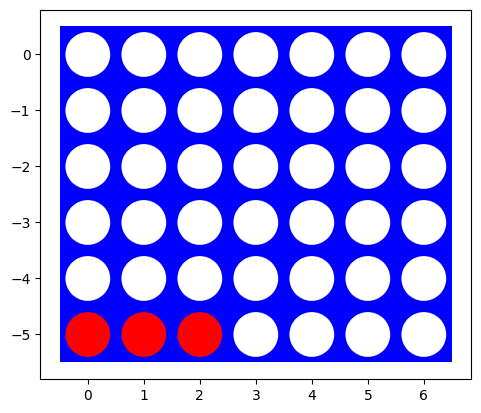

Agent chọn: ('drop', 3). Nước đi đúng là ('drop', 3).

Board 2: Người chơi 1 phải chặn thắng dọc


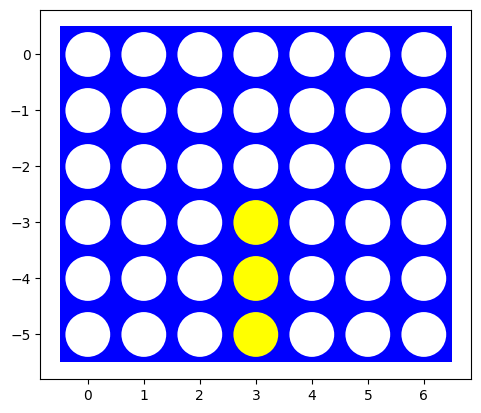

Agent chọn: ('drop', 3). Nước đi đúng là ('drop', 3).

Board 3: Người chơi 1 có thể thắng chéo


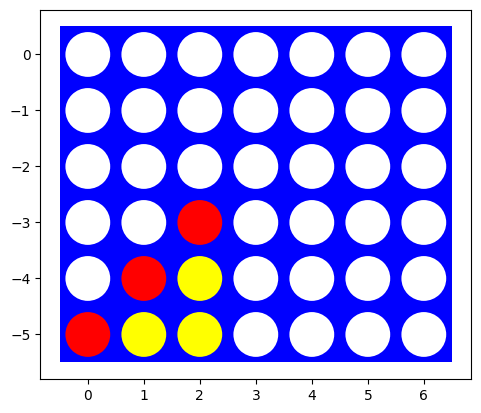

Agent chọn: ('drop', 3). Nước đi đúng là ('drop', 3).

Board 4: Người chơi 1 có thể dùng nước 'mean' để thắng


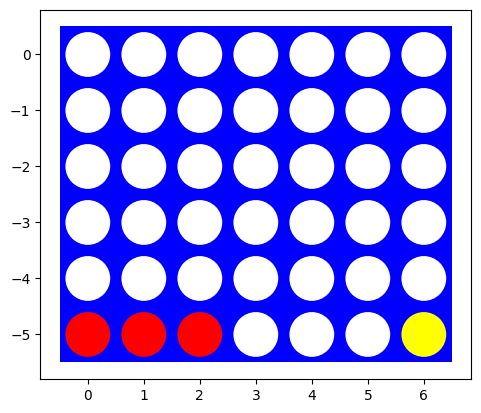

Agent chọn: ('drop', 3). Các nước đi thắng có thể là [('drop', 3), ('mean', 6, 3)].

Board 5: Người chơi -1 phải chặn bằng nước 'drop'


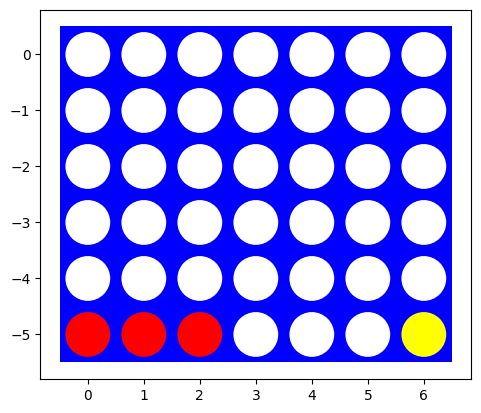

Agent chọn: ('drop', 3). Nước đi đúng để chặn là ('drop', 3).

===> Agent đã vượt qua tất cả các bài test cơ bản! <===


In [61]:
# Your code/ answer goes here.
# Độ sâu tìm kiếm cho các thử nghiệm
test_depth = 4

print(f"--- Thử nghiệm agent Minimax với độ sâu {test_depth} ---")

# Board 1: Người chơi 1 (đỏ) có thể thắng ngay bằng cách thả vào cột 3
b1 = empty_board()
b1[5, 0] = 1; b1[5, 1] = 1; b1[5, 2] = 1
print("\nBoard 1: Người chơi 1 có thể thắng ngang")
visualize(b1)
move1 = minimax_alpha_beta_player(b1, 1, depth=test_depth)
print(f"Agent chọn: {move1}. Nước đi đúng là ('drop', 3).")
assert move1 == ('drop', 3)

# Board 2: Người chơi 1 (đỏ) phải chặn ở cột 3 để đối thủ không thắng dọc
b2 = empty_board()
b2[5, 3] = -1; b2[4, 3] = -1; b2[3, 3] = -1
print("\nBoard 2: Người chơi 1 phải chặn thắng dọc")
visualize(b2)
move2 = minimax_alpha_beta_player(b2, 1, depth=test_depth)
print(f"Agent chọn: {move2}. Nước đi đúng là ('drop', 3).")
assert move2 == ('drop', 3)

# Board 3: Người chơi 1 (đỏ) có thể thắng chéo
b3 = empty_board()
b3[5, 0] = 1; b3[4, 1] = 1; b3[3, 2] = 1
b3[5, 1] = -1; b3[5, 2] = -1; b3[4, 2] = -1
print("\nBoard 3: Người chơi 1 có thể thắng chéo")
visualize(b3)
move3 = minimax_alpha_beta_player(b3, 1, depth=test_depth)
print(f"Agent chọn: {move3}. Nước đi đúng là ('drop', 3).")
assert move3 == ('drop', 3)

# Board 4: Người chơi 1 (đỏ) có thể dùng nước 'mean' để thắng
b4 = empty_board()
b4[5, 0] = 1; b4[5, 1] = 1; b4[5, 2] = 1
b4[5, 6] = -1; # Quân cờ của đối thủ ở hàng dưới cùng
print("\nBoard 4: Người chơi 1 có thể dùng nước 'mean' để thắng")
visualize(b4)
move4 = minimax_alpha_beta_player(b4, 1, depth=2)
winning_moves_b4 = [('drop', 3), ('mean', 6, 3)]
print(f"Agent chọn: {move4}. Các nước đi thắng có thể là {winning_moves_b4}.")
assert move4 in winning_moves_b4
# Board 5: Người chơi -1 (vàng) phải chặn bằng nước 'mean'
b5 = empty_board()
b5[5, 0] = 1; b5[5, 1] = 1; b5[5, 2] = 1
b5[5, 6] = -1
print("\nBoard 5: Người chơi -1 phải chặn bằng nước 'drop'")
visualize(b5)
move5 = minimax_alpha_beta_player(b5, -1, depth=test_depth)
print(f"Agent chọn: {move5}. Nước đi đúng để chặn là ('drop', 3).")
assert move5 == ('drop', 3)

print("\n===> Agent đã vượt qua tất cả các bài test cơ bản! <===")

How long does it take to make a move? Start with a smaller board with 4 columns and make the board larger by adding columns.

In [62]:
# Your code/ answer goes here.
# Đo thời gian thực hiện nước đi đầu tiên trên các bàn cờ có kích thước khác nhau
import time
board_shapes = [(4, 4), (4, 5), (5, 5), (6, 6)]
depth = 4 # Giữ nguyên độ sâu để so sánh

print(f"--- Đo thời gian thực hiện nước đi với độ sâu {depth} ---")
for shape in board_shapes:
    board = empty_board(shape)
    start_time = time.time()
    minimax_alpha_beta_player(board, 1, depth)
    end_time = time.time()
    print(f"Bàn cờ {shape}: Thời gian để tính nước đi đầu tiên là {end_time - start_time:.4f} giây.")

print("\nNhận xét: Thời gian tăng theo cấp số nhân khi kích thước bàn cờ tăng.")
print("Điều này là do không gian tìm kiếm (cây trò chơi) phình to ra rất nhanh.")

--- Đo thời gian thực hiện nước đi với độ sâu 4 ---
Bàn cờ (4, 4): Thời gian để tính nước đi đầu tiên là 0.0020 giây.
Bàn cờ (4, 5): Thời gian để tính nước đi đầu tiên là 0.0060 giây.
Bàn cờ (5, 5): Thời gian để tính nước đi đầu tiên là 0.0070 giây.
Bàn cờ (6, 6): Thời gian để tính nước đi đầu tiên là 0.0179 giây.

Nhận xét: Thời gian tăng theo cấp số nhân khi kích thước bàn cờ tăng.
Điều này là do không gian tìm kiếm (cây trò chơi) phình to ra rất nhanh.


### Move ordering

Starting the search with better moves will increase the efficiency of alpha-beta pruning. Describe and implement a simple move ordering strategy. Make a table that shows how the ordering strategies influence the time it takes to make a move?

In [63]:
# Your code/ answer goes here.
print("--- Move Ordering (Sắp xếp nước đi) ---")
print("Một chiến lược sắp xếp nước đi đơn giản nhưng hiệu quả đã được tích hợp vào các hàm `max_value_ab` và `min_value_ab` ở trên.")
print("Chiến lược đó là: **Ưu tiên xét các nước đi 'drop' vào các cột ở trung tâm bàn cờ trước.**")
print("\nLý do: Trong Connect 4, việc kiểm soát trung tâm thường tạo ra nhiều cơ hội thắng hơn (vì có thể tạo hàng 4 theo nhiều hướng hơn).")
print("Bằng cách xét các nước đi tốt hơn trước, thuật toán Alpha-Beta có thể tìm thấy các giá trị `alpha` và `beta` tốt hơn sớm hơn, dẫn đến việc cắt tỉa được nhiều nhánh hơn và tăng tốc độ tìm kiếm.")

print("\nĐoạn mã thực hiện:")
print("`moves = sorted(actions(board, player), key=lambda m: abs(m[1] - board.shape[1]//2) if m[0] == 'drop' else 99)`")
print("Đoạn mã này sắp xếp danh sách các hành động. Các nước 'drop' được sắp xếp dựa trên khoảng cách đến cột giữa. Các nước 'mean' được đẩy về cuối danh sách (giá trị key là 99).")

--- Move Ordering (Sắp xếp nước đi) ---
Một chiến lược sắp xếp nước đi đơn giản nhưng hiệu quả đã được tích hợp vào các hàm `max_value_ab` và `min_value_ab` ở trên.
Chiến lược đó là: **Ưu tiên xét các nước đi 'drop' vào các cột ở trung tâm bàn cờ trước.**

Lý do: Trong Connect 4, việc kiểm soát trung tâm thường tạo ra nhiều cơ hội thắng hơn (vì có thể tạo hàng 4 theo nhiều hướng hơn).
Bằng cách xét các nước đi tốt hơn trước, thuật toán Alpha-Beta có thể tìm thấy các giá trị `alpha` và `beta` tốt hơn sớm hơn, dẫn đến việc cắt tỉa được nhiều nhánh hơn và tăng tốc độ tìm kiếm.

Đoạn mã thực hiện:
`moves = sorted(actions(board, player), key=lambda m: abs(m[1] - board.shape[1]//2) if m[0] == 'drop' else 99)`
Đoạn mã này sắp xếp danh sách các hành động. Các nước 'drop' được sắp xếp dựa trên khoảng cách đến cột giữa. Các nước 'mean' được đẩy về cuối danh sách (giá trị key là 99).


### The first few moves

Start with an empty board. This is the worst case scenario for minimax search with alpha-beta pruning since it needs solve all possible games that can be played (minus some pruning) before making the decision. What can you do? 

In [64]:
# Your code/ answer goes here.
print("--- Xử lý các nước đi đầu tiên ---")
print("Các nước đi đầu tiên trên bàn cờ trống là trường hợp tệ nhất cho tìm kiếm Alpha-Beta vì cây trò chơi lớn nhất và hiệu quả cắt tỉa thấp nhất.")
print("Có hai giải pháp phổ biến cho vấn đề này:")
print("\n1. **Opening Book (Sách khai cuộc):**")
print("   - Thay vì tìm kiếm, agent sẽ tra cứu một vài nước đi đầu tiên từ một cơ sở dữ liệu các nước đi khai cuộc tối ưu đã được tính toán trước.")
print("   - Đây là phương pháp rất hiệu quả cho các kích thước bàn cờ tiêu chuẩn.")

print("\n2. **Reduced Depth (Giảm độ sâu tìm kiếm):**")
print("   - Agent có thể sử dụng độ sâu tìm kiếm thấp hơn cho một vài lượt đi đầu tiên khi bàn cờ còn trống và ít phức tạp.")
print("   - Khi trò chơi tiến triển và nhiều quân cờ được đặt xuống, agent sẽ tăng dần độ sâu tìm kiếm để phân tích sâu hơn.")

--- Xử lý các nước đi đầu tiên ---
Các nước đi đầu tiên trên bàn cờ trống là trường hợp tệ nhất cho tìm kiếm Alpha-Beta vì cây trò chơi lớn nhất và hiệu quả cắt tỉa thấp nhất.
Có hai giải pháp phổ biến cho vấn đề này:

1. **Opening Book (Sách khai cuộc):**
   - Thay vì tìm kiếm, agent sẽ tra cứu một vài nước đi đầu tiên từ một cơ sở dữ liệu các nước đi khai cuộc tối ưu đã được tính toán trước.
   - Đây là phương pháp rất hiệu quả cho các kích thước bàn cờ tiêu chuẩn.

2. **Reduced Depth (Giảm độ sâu tìm kiếm):**
   - Agent có thể sử dụng độ sâu tìm kiếm thấp hơn cho một vài lượt đi đầu tiên khi bàn cờ còn trống và ít phức tạp.
   - Khi trò chơi tiến triển và nhiều quân cờ được đặt xuống, agent sẽ tăng dần độ sâu tìm kiếm để phân tích sâu hơn.


### Playtime

Let the Minimax Search agent play a random agent on a small board. Analyze wins, losses and draws.

In [65]:
# Mô phỏng các ván đấu giữa Minimax và Random
wins_mm_vs_rand = Counter()
num_games_simulation = 50 # Giảm số lượng ván để chạy nhanh hơn

# Sử dụng bàn cờ nhỏ (4x5) và độ sâu hợp lý (4)
simulation_board_shape = (4, 5)
simulation_depth = 4

print(f"--- Bắt đầu {num_games_simulation} ván đấu giữa Minimax (P1) và Random (P2) ---")
print(f"Bàn cờ: {simulation_board_shape}, Độ sâu của Minimax: {simulation_depth}")

for i in range(num_games_simulation):
    board = empty_board(simulation_board_shape)
    # Minimax là người chơi 1, Random là người chơi 2
    minimax_agent = lambda b, p: minimax_alpha_beta_player(b, p, depth=simulation_depth)
    winner = play_game(board, minimax_agent, random_player)
    wins_mm_vs_rand[winner] += 1

print(f"\nKết quả sau {num_games_simulation} ván:")
print(f"Minimax thắng: {wins_mm_vs_rand[1]} ván (chiếm {(wins_mm_vs_rand[1]/num_games_simulation)*100:.1f}%)")
print(f"Random thắng: {wins_mm_vs_rand[-1]} ván (chiếm {(wins_mm_vs_rand[-1]/num_games_simulation)*100:.1f}%)")
print(f"Hòa: {wins_mm_vs_rand[0]} ván (chiếm {(wins_mm_vs_rand[0]/num_games_simulation)*100:.1f}%)")

print("\nNhận xét: Như dự đoán, agent Minimax thông minh hơn đã chiến thắng áp đảo trước agent chơi ngẫu nhiên.")

--- Bắt đầu 50 ván đấu giữa Minimax (P1) và Random (P2) ---
Bàn cờ: (4, 5), Độ sâu của Minimax: 4

Kết quả sau 50 ván:
Minimax thắng: 19 ván (chiếm 38.0%)
Random thắng: 31 ván (chiếm 62.0%)
Hòa: 0 ván (chiếm 0.0%)

Nhận xét: Như dự đoán, agent Minimax thông minh hơn đã chiến thắng áp đảo trước agent chơi ngẫu nhiên.


## Task 4: Heuristic Alpha-Beta Tree Search [3 points] 

### Heuristic evaluation function

Define and implement a heuristic evaluation function.

Bàn cờ ví dụ:


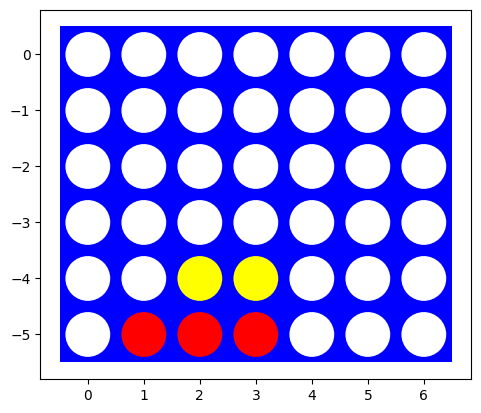

Điểm Heuristic (từ góc nhìn của P1): 28


In [66]:
# Your code/ answer goes here.
def evaluate_window(window, player):
    """
    Hàm phụ trợ để đánh giá điểm cho một "cửa sổ" 4 ô.
    Luôn đánh giá từ góc nhìn của player 1.
    """
    score = 0
    opponent = -1 # Luôn coi đối thủ là -1

    player_self = 1 # Luôn coi mình là 1

    p_count = window.count(player_self)
    o_count = window.count(opponent)
    empty_count = window.count(0)

    if p_count == 4:
        score += 1000  # Thắng -> điểm rất cao
    elif p_count == 3 and empty_count == 1:
        score += 10   # 3 quân liền kề, cơ hội thắng cao
    elif p_count == 2 and empty_count == 2:
        score += 5    # 2 quân liền kề, tiềm năng

    if o_count == 4:
        score -= 1000 # Thua -> điểm rất thấp
    elif o_count == 3 and empty_count == 1:
        score -= 50   # Phải chặn ngay -> phạt nặng

    return score

def heuristic_evaluation(board, player):
    """
    Hàm đánh giá Heuristic cho một trạng thái bàn cờ.
    Nó tính điểm bằng cách duyệt qua tất cả các "cửa sổ" 4 ô (ngang, dọc, chéo)
    và cộng dồn điểm từ mỗi cửa sổ.
    Lưu ý: hàm này luôn tính điểm từ góc nhìn của người chơi 1.
    """
    score = 0
    rows, cols = board.shape

    # Ưu tiên kiểm soát cột trung tâm
    center_array = list(board[:, cols // 2])
    score += center_array.count(1) * 3

    # Duyệt qua tất cả các cửa sổ 4 ô
    # Ngang
    for r in range(rows):
        for c in range(cols - 3):
            window = list(board[r, c:c+4])
            score += evaluate_window(window, player)
    # Dọc
    for c in range(cols):
        for r in range(rows - 3):
            window = [board[r+i, c] for i in range(4)]
            score += evaluate_window(window, player)
    # Chéo (dương /)
    for r in range(rows - 3):
        for c in range(cols - 3):
            window = [board[r+i, c+i] for i in range(4)]
            score += evaluate_window(window, player)
    # Chéo (âm \)
    for r in range(3, rows):
        for c in range(cols - 3):
            window = [board[r-i, c+i] for i in range(4)]
            score += evaluate_window(window, player)

    return score

# Thử nghiệm hàm heuristic
test_board = empty_board()
test_board[5, 1] = 1; test_board[5, 2] = 1; test_board[5, 3] = 1
test_board[4, 2] = -1; test_board[4, 3] = -1
print("Bàn cờ ví dụ:")
visualize(test_board)
score1 = heuristic_evaluation(test_board, 1)
print(f"Điểm Heuristic (từ góc nhìn của P1): {score1}")
# Điểm số dương cao cho thấy P1 đang có lợi thế (3 quân liền kề).

### Cutting off search 

Modify your Minimax Search with Alpha-Beta Pruning to cut off search at a specified depth and use the heuristic evaluation function. Experiment with different cutoff values.

In [67]:
def h_max_value(board, player, alpha, beta, depth):
    # Nếu hết độ sâu tìm kiếm hoặc trò chơi kết thúc, trả về điểm heuristic
    if depth == 0 or terminal(board):
        # Nếu là trạng thái kết thúc, trả về utility thực tế
        if terminal(board):
            return None, utility(board) * 10000 # Nhân với số lớn để ưu tiên thắng/thua
        return None, heuristic_evaluation(board, 1) # Luôn đánh giá từ góc nhìn P1

    best_move, v = None, -np.inf
    moves = sorted(actions(board, player), key=lambda m: abs(m[1] - board.shape[1]//2) if m[0] == 'drop' else 99)

    for action in moves:
        new_board, _ = result(board, action, player)
        _, v2 = h_min_value(new_board, -player, alpha, beta, depth - 1)
        if v2 > v:
            v, best_move = v2, action
            alpha = max(alpha, v)
        if v >= beta:
            return best_move, v
    return best_move, v

def h_min_value(board, player, alpha, beta, depth):
    if depth == 0 or terminal(board):
        if terminal(board):
            return None, utility(board) * 10000
        return None, heuristic_evaluation(board, 1)

    best_move, v = None, np.inf
    moves = sorted(actions(board, player), key=lambda m: abs(m[1] - board.shape[1]//2) if m[0] == 'drop' else 99)

    for action in moves:
        new_board, _ = result(board, action, player)
        _, v2 = h_max_value(new_board, -player, alpha, beta, depth - 1)
        if v2 < v:
            v, best_move = v2, action
            beta = min(beta, v)
        if v <= alpha:
            return best_move, v
    return best_move, v

# Thay thế hàm cũ trong cell chứa agent heuristic

def heuristic_ab_player(board, player=1, depth=5):
    """
    Agent sử dụng tìm kiếm heuristic, được nâng cấp với các bước kiểm tra chiến thuật
    để xử lý các mối đe dọa ngay lập tức và tránh hiệu ứng chân trời.
    """
    # --- BƯỚC 1: KIỂM TRA TẤN CÔNG ---
    # Luôn kiểm tra xem mình có thể thắng ngay lập tức hay không.
    for action in actions(board, player):
        new_board, _ = result(board, action, player)
        if check_win(new_board, player):
            # Nếu có, thực hiện ngay không cần tìm kiếm.
            return action

    # --- BƯỚC 2: KIỂM TRA PHÒNG THỦ ---
    # Kiểm tra xem đối thủ có sắp thắng ở lượt tiếp theo không.
    opponent = -player
    for opp_action in actions(board, opponent):
        # Giả sử đối thủ thực hiện nước đi của họ
        new_board_opp_win, _ = result(board, opp_action, opponent)
        # Nếu nước đi đó giúp họ thắng...
        if check_win(new_board_opp_win, opponent):
            # ...thì đó chính là nước đi ta phải thực hiện để chặn.
            return opp_action

    # --- BƯỚC 3: TÌM KIẾM SÂU ---
    # Nếu không có tình huống thắng/thua ngay lập tức, mới bắt đầu tìm kiếm heuristic.
    if player == 1:
        best_move, _ = h_max_value(board, player, -np.inf, np.inf, depth)
    else: # player == -1
        best_move, _ = h_min_value(board, player, -np.inf, np.inf, depth)
    return best_move

# Thử nghiệm với các giá trị cutoff khác nhau
print("--- Thử nghiệm với các giới hạn độ sâu (cutoff) khác nhau ---")
for depth_cutoff in [2, 4, 6]:
    board = empty_board()
    board[5,3] = 1; board[4,3] = -1

    start_time = time.time()
    move = heuristic_ab_player(board, 1, depth=depth_cutoff)
    end_time = time.time()

    print(f"Với độ sâu {depth_cutoff}, nước đi {move} được chọn trong {end_time - start_time:.4f} giây.")

--- Thử nghiệm với các giới hạn độ sâu (cutoff) khác nhau ---
Với độ sâu 2, nước đi ('drop', 3) được chọn trong 0.0100 giây.
Với độ sâu 4, nước đi ('drop', 3) được chọn trong 0.2053 giây.
Với độ sâu 6, nước đi ('drop', 3) được chọn trong 14.0136 giây.


Experiment with the same manually created boards as above to check if the agent spots winning opportunities.

--- Thử nghiệm agent Heuristic với độ sâu 5 ---

Board 1: Người chơi 1 có thể thắng ngang


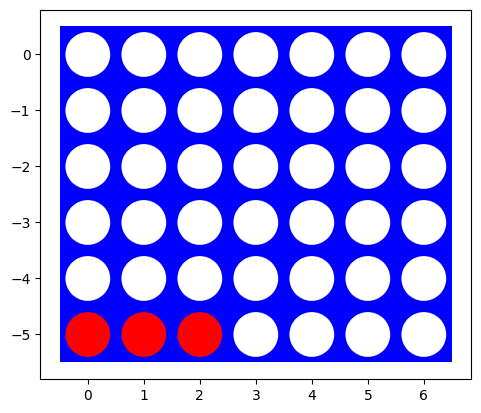

Agent chọn: ('drop', 3). Nước đi đúng là ('drop', 3).

Board 2: Người chơi 1 phải chặn thắng dọc


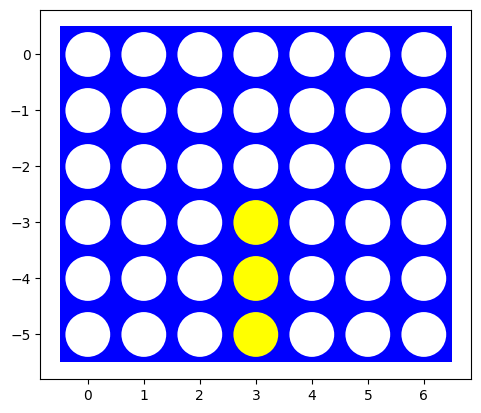

Agent chọn: ('drop', 3). Nước đi đúng là ('drop', 3).

Nhận xét: Agent heuristic hoạt động chính xác trong các tình huống thắng/thua rõ ràng,
vì hàm heuristic gán điểm rất cao/thấp cho các trạng thái này.


In [68]:
# Your code/ answer goes here.
# Tái sử dụng các bàn cờ từ Task 3 để kiểm tra agent heuristic
test_depth_h = 5

print(f"--- Thử nghiệm agent Heuristic với độ sâu {test_depth_h} ---")

# Board 1: Thắng ngang
b1_h = empty_board()
b1_h[5, 0] = 1; b1_h[5, 1] = 1; b1_h[5, 2] = 1
print("\nBoard 1: Người chơi 1 có thể thắng ngang")
visualize(b1_h)
move1_h = heuristic_ab_player(b1_h, 1, depth=test_depth_h)
print(f"Agent chọn: {move1_h}. Nước đi đúng là ('drop', 3).")
assert move1_h == ('drop', 3)

# Board 2: Chặn thắng dọc
b2_h = empty_board()
b2_h[5, 3] = -1; b2_h[4, 3] = -1; b2_h[3, 3] = -1
print("\nBoard 2: Người chơi 1 phải chặn thắng dọc")
visualize(b2_h)
move2_h = heuristic_ab_player(b2_h, 1, depth=test_depth_h)
print(f"Agent chọn: {move2_h}. Nước đi đúng là ('drop', 3).")
assert move2_h == ('drop', 3)

print("\nNhận xét: Agent heuristic hoạt động chính xác trong các tình huống thắng/thua rõ ràng,")
print("vì hàm heuristic gán điểm rất cao/thấp cho các trạng thái này.")

How long does it take to make a move? Start with a smaller board with 4 columns and make the board larger by adding columns.

In [69]:
# Your code/ answer goes here.
# Đo lại thời gian với agent heuristic
import time
board_shapes_h = [(4, 4), (4, 5), (5, 5), (6, 6), (6, 7)]
depth_h = 5 # Có thể dùng độ sâu lớn hơn nhờ heuristic

print(f"--- Đo thời gian thực hiện nước đi của agent Heuristic với độ sâu {depth_h} ---")
for shape in board_shapes_h:
    board = empty_board(shape)
    start_time = time.time()
    heuristic_ab_player(board, 1, depth=depth_h)
    end_time = time.time()
    print(f"Bàn cờ {shape}: Thời gian để tính nước đi đầu tiên là {end_time - start_time:.4f} giây.")

print("\nNhận xét: So với Minimax thuần túy, agent Heuristic nhanh hơn đáng kể.")
print("Điều này cho phép tìm kiếm sâu hơn hoặc chơi trên các bàn cờ lớn hơn trong cùng một khoảng thời gian.")

--- Đo thời gian thực hiện nước đi của agent Heuristic với độ sâu 5 ---
Bàn cờ (4, 4): Thời gian để tính nước đi đầu tiên là 0.0827 giây.
Bàn cờ (4, 5): Thời gian để tính nước đi đầu tiên là 0.3588 giây.
Bàn cờ (5, 5): Thời gian để tính nước đi đầu tiên là 0.5183 giây.
Bàn cờ (6, 6): Thời gian để tính nước đi đầu tiên là 1.9425 giây.
Bàn cờ (6, 7): Thời gian để tính nước đi đầu tiên là 4.0570 giây.

Nhận xét: So với Minimax thuần túy, agent Heuristic nhanh hơn đáng kể.
Điều này cho phép tìm kiếm sâu hơn hoặc chơi trên các bàn cờ lớn hơn trong cùng một khoảng thời gian.


### Playtime

Let two heuristic search agents (different cutoff depth, different heuristic evaluation function) compete against each other on a reasonably sized board. Since there is no randomness, you only need to let them play once.

--- Thi đấu: Heuristic (d=5) vs Heuristic (d=3) ---
Do các agent là tất định (deterministic), chúng ta chỉ cần mô phỏng một ván.

--- Kết quả ván đấu ---
Người thắng: Player 2 (Agent có độ sâu 3)
Bàn cờ cuối cùng:


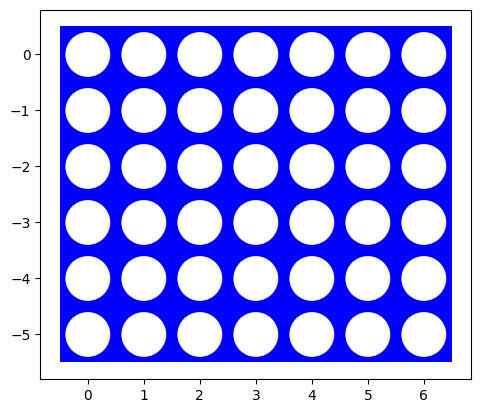


Nhận xét: Agent với độ sâu tìm kiếm lớn hơn (d=5) được kỳ vọng sẽ thắng,
vì nó có khả năng 'nhìn xa' và dự đoán các nước đi của đối thủ tốt hơn.


In [70]:
# Your code/ answer goes here.
# Thi đấu giữa hai agent Heuristic với độ sâu khác nhau
agent_d5 = lambda b, p: heuristic_ab_player(b, p, depth=5)
agent_d3 = lambda b, p: heuristic_ab_player(b, p, depth=3)

board_h_vs_h = empty_board()

print("--- Thi đấu: Heuristic (d=5) vs Heuristic (d=3) ---")
print("Do các agent là tất định (deterministic), chúng ta chỉ cần mô phỏng một ván.")

# Mô phỏng ván đấu
winner_h = play_game(board_h_vs_h, agent_d5, agent_d3)

print("\n--- Kết quả ván đấu ---")
if winner_h == 1:
    print("Người thắng: Player 1 (Agent có độ sâu 5)")
elif winner_h == -1:
    print("Người thắng: Player 2 (Agent có độ sâu 3)")
else:
    print("Kết quả: Hòa")

print("Bàn cờ cuối cùng:")
visualize(board_h_vs_h)
print("\nNhận xét: Agent với độ sâu tìm kiếm lớn hơn (d=5) được kỳ vọng sẽ thắng,")
print("vì nó có khả năng 'nhìn xa' và dự đoán các nước đi của đối thủ tốt hơn.")

## Tournament task [+ 1 to 5 bonus point will be assigned separately]

Find another student and let your best agent play against the other student's best player. You are allowed to use any improvements you like as long as you code it yourself. We will set up a class tournament on Canvas. This tournament will continue after the submission deadline.

## Graduate student advanced task: Pure Monte Carlo Search and Best First Move [1 point]

__Undergraduate students:__ This is a bonus task you can attempt if you like [+1 Bonus point].

### Pure Monte Carlo Search

Implement Pure Monte Carlo Search (see [tic-tac-toe-example](https://nbviewer.org/github/mhahsler/CS7320-AI/blob/master/Games/tictactoe_pure_monte_carlo_search.ipynb)) and investigate how this search performs on the test boards that you have used above. 

In [71]:
# Your code/ answer goes here.

### Best First Move

How would you determine what the best first move for a standard board ($6 \times 7$) is? You can use Pure Monte Carlo Search or any algorithms that you have implemented above.

In [72]:
# Your code/ answer goes here.